# Training Run Report Dashboard

This notebook builds a reusable report for a training run stored in a demo-model directory such as `MelCNN-MGR/demo-models/logmel-cnn-v2_4-cuda-tf-20260318-104959_15s`.

It extracts structured metrics from the run artifacts, renders summary tables, training curves, per-genre evaluation charts, normalization diagnostics, artifact inventory, and automatically generated insights.

## Expected inputs inside the run directory
- `run_report_*.json`
- `console_output.txt`
- `normalization_stats.json`
- `norm_stats.npz`
- one or more `.keras` model files (optional for model inspection)

Update `RUN_DIR` in the next cell to analyze a different run.

## Music Genre Prediction Using Log-Mel Spectrograms and CNNs

***By Nguyễn Sỹ Hùng (25MSA33055)***

Machine Learning 1, FSB, 2026


In [38]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('default')

RUN_DIR = Path('../demo-models/logmel-cnn-v2_4-cuda-tf-20260318-104959_15s').resolve()
FIG_DPI = 130
pd.options.display.float_format = '{:.4f}'.format

display(Markdown(f'**Active run directory:** `{RUN_DIR}`'))

**Active run directory:** `/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/demo-models/logmel-cnn-v2_4-cuda-tf-20260318-104959_15s`

In [39]:
def _to_float(value):
    if value in (None, 'n/a', 'NA', 'NaN', ''):
        return np.nan
    return float(value)


def _find_first(run_dir, patterns):
    for pattern in patterns:
        matches = sorted(run_dir.glob(pattern))
        if matches:
            return matches[0]
    return None


def _extract_npz_array(npz_file, candidates):
    if npz_file is None:
        return None
    for key in candidates:
        if key in npz_file.files:
            return np.asarray(npz_file[key])
    return None


def parse_epoch_summaries(console_text):
    pattern = re.compile(
        r'\[EpochSummary\]\s+'
        r'(?P<epoch>\d+)/(?P<epochs_max>\d+)\s+'
        r'train_loss=(?P<train_loss>[0-9.]+|n/a)\s+'
        r'val_loss=(?P<val_loss>[0-9.]+|n/a)\s+'
        r'train_acc=(?P<train_acc>[0-9.]+|n/a)\s+'
        r'val_acc=(?P<val_acc>[0-9.]+|n/a)\s+'
        r'train_macro_f1=(?P<train_macro_f1>[0-9.]+|n/a)\s+'
        r'val_macro_f1=(?P<val_macro_f1>[0-9.]+|n/a)'
        r'(?:\s+acc_gap=(?P<acc_gap>-?[0-9.]+|n/a)\s+'
        r'f1_gap=(?P<f1_gap>-?[0-9.]+|n/a))?'
        r'(?:\s+\|.*)?'
    )
    rows = []
    for match in pattern.finditer(console_text):
        row = match.groupdict()
        rows.append({
            'epoch': int(row['epoch']),
            'epochs_max': int(row['epochs_max']),
            'train_loss': _to_float(row['train_loss']),
            'val_loss': _to_float(row['val_loss']),
            'train_acc': _to_float(row['train_acc']),
            'val_acc': _to_float(row['val_acc']),
            'acc_gap': _to_float(row.get('acc_gap')),
            'train_macro_f1': _to_float(row['train_macro_f1']),
            'val_macro_f1': _to_float(row['val_macro_f1']),
            'f1_gap': _to_float(row.get('f1_gap')),
        })
    return pd.DataFrame(rows)


def extract_restore_epoch(console_text):
    match = re.search(r'best epoch:\s*(\d+)', console_text)
    return int(match.group(1)) if match else None


def extract_class_weights(console_text, genres):
    lines = console_text.splitlines()
    weights = {}
    start_idx = None
    for idx, line in enumerate(lines):
        if 'class weight' in line.lower():
            start_idx = idx
            break
    if start_idx is None:
        return weights

    for line in lines[start_idx:start_idx + 40]:
        stripped = line.strip().lstrip('-').strip()
        for genre in genres:
            match = re.match(rf'^{re.escape(genre)}\s+([0-9]*\.?[0-9]+)(?:\s+\(raw:\s*[0-9]*\.?[0-9]+\))?$', stripped)
            if match:
                weights[genre] = float(match.group(1))
    return weights


def build_overall_metrics(report):
    rows = []
    for split_key, split_label in [('train', 'Train'), ('validation', 'Validation'), ('test', 'Test')]:
        split_report = report['evaluation'][split_key]
        rows.append({
            'split': split_label,
            'loss': split_report['cost'],
            'accuracy': split_report['accuracy'],
            'accuracy_pct': split_report['accuracy'] * 100.0,
            'macro_f1': split_report['macro_f1'],
            'macro_f1_pct': split_report['macro_f1'] * 100.0,
        })
    return pd.DataFrame(rows)


def build_per_genre_frames(report):
    frames = {}
    for split_key, split_label in [('train', 'Train'), ('validation', 'Validation'), ('test', 'Test')]:
        records = []
        for genre, metrics in report['evaluation'][split_key]['per_genre'].items():
            records.append({
                'genre': genre,
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1-score': metrics['f1-score'],
                'support': int(metrics['support']),
            })
        frames[split_label] = pd.DataFrame(records).sort_values('genre').reset_index(drop=True)
    return frames


def build_changes_table(report):
    rows = []
    for key in ['changes_from_v2_1', 'changes_from_v2_2', 'changes_from_v2_3']:
        if key not in report:
            continue
        for name, description in report[key].items():
            rows.append({
                'source_version': key.replace('changes_from_', '').replace('_', '.'),
                'change': name,
                'description': description,
            })
    return pd.DataFrame(rows)


def load_run_bundle(run_dir):
    run_dir = Path(run_dir).resolve()
    if not run_dir.exists():
        raise FileNotFoundError(f'Run directory not found: {run_dir}')

    report_path = _find_first(run_dir, ['run_report_*.json'])
    console_path = _find_first(run_dir, ['console_output.txt'])
    norm_meta_path = _find_first(run_dir, ['normalization_stats.json'])
    norm_npz_path = _find_first(run_dir, ['norm_stats.npz'])
    model_paths = sorted(run_dir.glob('*.keras'))

    if report_path is None:
        raise FileNotFoundError('Could not find run_report_*.json in the run directory.')

    with report_path.open('r', encoding='utf-8') as f:
        report = json.load(f)

    console_text = ''
    if console_path is not None:
        console_text = console_path.read_text(encoding='utf-8', errors='ignore')

    norm_meta = {}
    if norm_meta_path is not None:
        with norm_meta_path.open('r', encoding='utf-8') as f:
            norm_meta = json.load(f)

    norm_npz = np.load(norm_npz_path, allow_pickle=False) if norm_npz_path is not None else None
    epochs_df = parse_epoch_summaries(console_text)
    genres = report['dataset']['genres']
    class_weights = extract_class_weights(console_text, genres)

    return {
        'run_dir': run_dir,
        'report_path': report_path,
        'console_path': console_path,
        'norm_meta_path': norm_meta_path,
        'norm_npz_path': norm_npz_path,
        'model_paths': model_paths,
        'report': report,
        'console_text': console_text,
        'norm_meta': norm_meta,
        'norm_npz': norm_npz,
        'norm_mean': _extract_npz_array(norm_npz, ['mean_per_bin', 'mean', 'mu']),
        'norm_std': _extract_npz_array(norm_npz, ['std_per_bin', 'std', 'sigma']),
        'epochs_df': epochs_df,
        'restore_epoch': extract_restore_epoch(console_text),
        'class_weights': class_weights,
    }

In [40]:
bundle = load_run_bundle(RUN_DIR)
report = bundle['report']
epochs_df = bundle['epochs_df']
overall_df = build_overall_metrics(report)
per_genre_frames = build_per_genre_frames(report)
changes_df = build_changes_table(report)

training_seconds = float(np.sum(report['training'].get('seconds_per_epoch', [])))
training_hours = training_seconds / 3600.0 if training_seconds else np.nan
checkpoint_epoch = report['training'].get('best_epoch_macro_f1')
restore_epoch = bundle['restore_epoch']

overview_df = pd.DataFrame([
    {'field': 'run_id', 'value': report['run_id']},
    {'field': 'generated_at', 'value': report['generated_at']},
    {'field': 'dataset_format', 'value': report['dataset']['format']},
    {'field': 'classes', 'value': report['dataset']['n_classes']},
    {'field': 'genres', 'value': ', '.join(report['dataset']['genres'])},
    {'field': 'train_samples', 'value': report['dataset']['train_samples']},
    {'field': 'validation_samples', 'value': report['dataset']['val_samples']},
    {'field': 'test_samples', 'value': report['dataset']['test_samples']},
    {'field': 'epochs_actual', 'value': report['training']['epochs_actual']},
    {'field': 'epochs_max', 'value': report['training']['epochs_max']},
    {'field': 'test_accuracy_pct', 'value': report['evaluation']['test']['accuracy'] * 100.0},
    {'field': 'test_macro_f1_pct', 'value': report['evaluation']['test']['macro_f1'] * 100.0},
    {'field': 'training_hours', 'value': training_hours},
    {'field': 'best_checkpoint_epoch', 'value': checkpoint_epoch},
    {'field': 'restored_epoch', 'value': restore_epoch},
])

artifact_df = pd.DataFrame([
    {'artifact': 'run_report', 'path': str(bundle['report_path'])},
    {'artifact': 'console_output', 'path': str(bundle['console_path']) if bundle['console_path'] else None},
    {'artifact': 'normalization_metadata', 'path': str(bundle['norm_meta_path']) if bundle['norm_meta_path'] else None},
    {'artifact': 'normalization_arrays', 'path': str(bundle['norm_npz_path']) if bundle['norm_npz_path'] else None},
] + [
    {'artifact': f'model_{idx + 1}', 'path': str(path)}
    for idx, path in enumerate(bundle['model_paths'])
])

display(Markdown('## Run Overview'))
display(overview_df)
display(Markdown('## Artifact Inventory'))
display(artifact_df)

## Run Overview

,field,value
0,run_id,logmel-cnn-v2_4-cuda-tf-20260318-104959
1,generated_at,2026-03-18 16:38:03
2,dataset_format,tfrecord
3,classes,10
4,genres,"Blues, Bolero, Classical, Country, Hip-Hop, Ja..."
5,train_samples,15410
6,validation_samples,3309
7,test_samples,3309
8,epochs_actual,85
9,epochs_max,136


## Artifact Inventory

,artifact,path
0,run_report,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...
1,console_output,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...
2,normalization_metadata,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...
3,normalization_arrays,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...
4,model_1,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...
5,model_2,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...


## Split-Level Metrics

,split,loss,accuracy,accuracy_pct,macro_f1,macro_f1_pct
0,Train,0.4369,0.9570,95.7000,0.9572,95.7200
1,Validation,0.6559,0.8670,86.7000,0.8667,86.6700
2,Test,0.6597,0.8707,87.0700,0.8695,86.9500


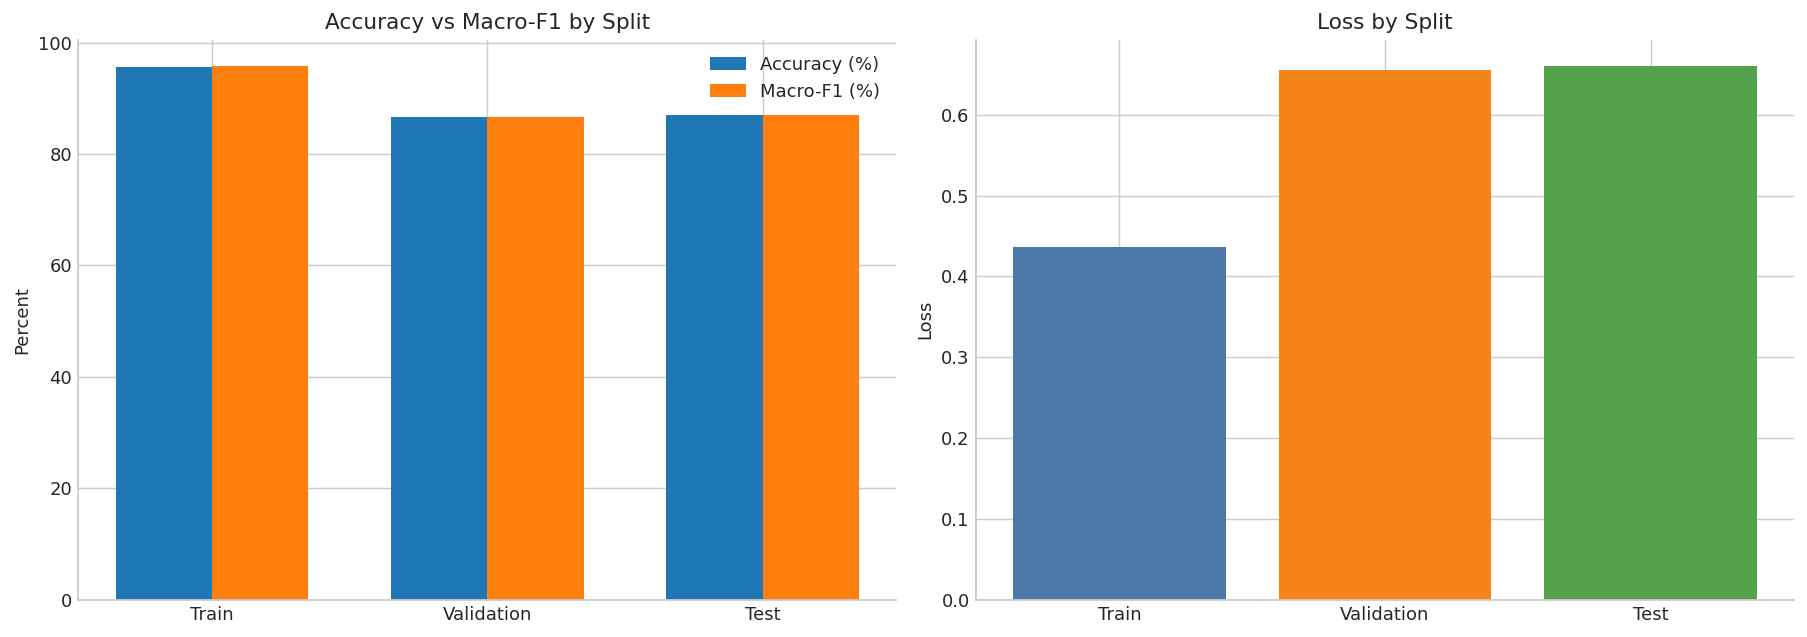

**Train-Test macro-F1 gap:** 0.0877 (8.77 percentage points)

## Overfitting Assessment

,comparison,accuracy_gap_pp,macro_f1_gap_pp,loss_gap
0,Train - Validation,9.0000,9.0500,-0.2190
1,Train - Test,8.6300,8.7700,-0.2228
2,Validation - Test,-0.3700,-0.2800,-0.0038
3,|Validation - Test|,0.3700,0.2800,0.0038


,assessment,value
0,Bias label,Low bias
1,Variance label,Moderate variance
2,Overfitting verdict,"Some overfitting, but still generalizing well"
3,Train vs holdout accuracy gap (pp),8.8150
4,Train vs holdout macro-F1 gap (pp),8.9100
5,Validation vs test accuracy gap (pp),0.3700
6,Validation vs test macro-F1 gap (pp),0.2800


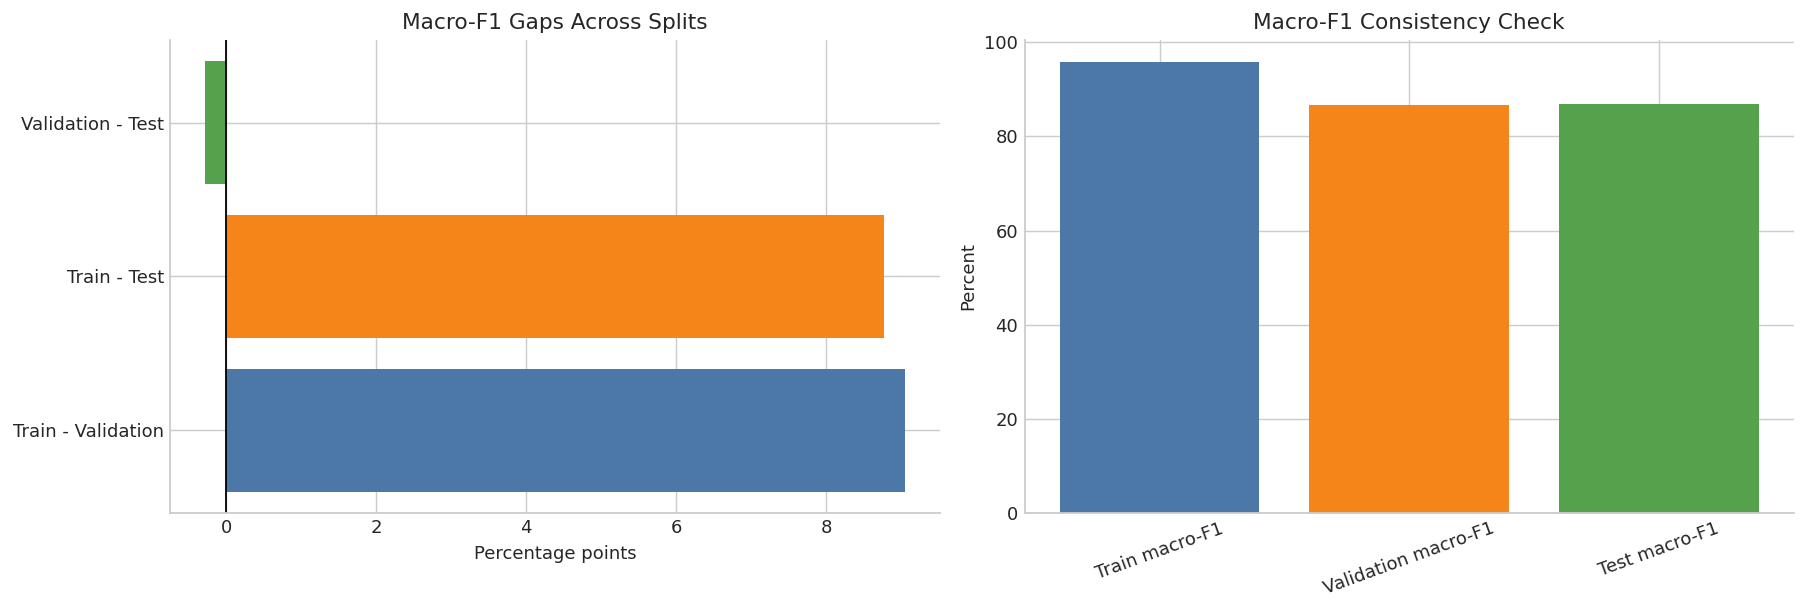

- **Bias:** Low bias. Train macro-F1 is 95.72% and the holdout average of validation/test macro-F1 is 86.81%.
- **Variance:** Moderate variance. The train-to-holdout macro-F1 gap is 8.91 percentage points.
- **Validation-test consistency:** the absolute validation-test macro-F1 gap is 0.28 percentage points, which is the main check for whether the apparent variance is harming real generalization.
- **Verdict:** Some overfitting, but still generalizing well.
- These labels are heuristic and are meant to summarize the saved metrics, not replace domain judgment.

In [41]:
display(Markdown('## Split-Level Metrics'))
display(overall_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

metric_positions = np.arange(len(overall_df))
width = 0.35
axes[0].bar(metric_positions - width / 2, overall_df['accuracy_pct'], width=width, label='Accuracy (%)', color='#1f77b4')
axes[0].bar(metric_positions + width / 2, overall_df['macro_f1_pct'], width=width, label='Macro-F1 (%)', color='#ff7f0e')
axes[0].set_xticks(metric_positions)
axes[0].set_xticklabels(overall_df['split'])
axes[0].set_ylabel('Percent')
axes[0].set_title('Accuracy vs Macro-F1 by Split')
axes[0].legend()

axes[1].bar(overall_df['split'], overall_df['loss'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss by Split')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

train_test_gap = report['evaluation']['train']['macro_f1'] - report['evaluation']['test']['macro_f1']
display(Markdown(f'**Train-Test macro-F1 gap:** {train_test_gap:.4f} ({train_test_gap * 100:.2f} percentage points)'))

display(Markdown('## Overfitting Assessment'))

train_eval = report['evaluation']['train']
val_eval = report['evaluation']['validation']
test_eval = report['evaluation']['test']

gap_rows = [
    {
        'comparison': 'Train - Validation',
        'accuracy_gap_pp': (train_eval['accuracy'] - val_eval['accuracy']) * 100.0,
        'macro_f1_gap_pp': (train_eval['macro_f1'] - val_eval['macro_f1']) * 100.0,
        'loss_gap': train_eval['cost'] - val_eval['cost'],
    },
    {
        'comparison': 'Train - Test',
        'accuracy_gap_pp': (train_eval['accuracy'] - test_eval['accuracy']) * 100.0,
        'macro_f1_gap_pp': (train_eval['macro_f1'] - test_eval['macro_f1']) * 100.0,
        'loss_gap': train_eval['cost'] - test_eval['cost'],
    },
    {
        'comparison': 'Validation - Test',
        'accuracy_gap_pp': (val_eval['accuracy'] - test_eval['accuracy']) * 100.0,
        'macro_f1_gap_pp': (val_eval['macro_f1'] - test_eval['macro_f1']) * 100.0,
        'loss_gap': val_eval['cost'] - test_eval['cost'],
    },
    {
        'comparison': '|Validation - Test|',
        'accuracy_gap_pp': abs(val_eval['accuracy'] - test_eval['accuracy']) * 100.0,
        'macro_f1_gap_pp': abs(val_eval['macro_f1'] - test_eval['macro_f1']) * 100.0,
        'loss_gap': abs(val_eval['cost'] - test_eval['cost']),
    },
]
gap_df = pd.DataFrame(gap_rows)
display(gap_df)

holdout_macro_f1 = (val_eval['macro_f1'] + test_eval['macro_f1']) / 2.0
generalization_gap_f1 = train_eval['macro_f1'] - holdout_macro_f1
generalization_gap_acc = train_eval['accuracy'] - ((val_eval['accuracy'] + test_eval['accuracy']) / 2.0)
val_test_gap_f1 = abs(val_eval['macro_f1'] - test_eval['macro_f1'])
val_test_gap_acc = abs(val_eval['accuracy'] - test_eval['accuracy'])

if train_eval['macro_f1'] >= 0.90 and holdout_macro_f1 >= 0.80:
    bias_label = 'Low bias'
elif train_eval['macro_f1'] >= 0.80 and holdout_macro_f1 >= 0.70:
    bias_label = 'Moderate bias'
else:
    bias_label = 'High bias'

if generalization_gap_f1 > 0.15 or val_test_gap_f1 > 0.05:
    variance_label = 'High variance'
elif generalization_gap_f1 > 0.07 or val_test_gap_f1 > 0.02:
    variance_label = 'Moderate variance'
else:
    variance_label = 'Low variance'

if variance_label == 'High variance' and val_test_gap_f1 > 0.03:
    overfitting_label = 'Likely overfitting'
elif variance_label == 'Moderate variance' and val_test_gap_f1 <= 0.02:
    overfitting_label = 'Some overfitting, but still generalizing well'
else:
    overfitting_label = 'No strong overfitting signal'

assessment_df = pd.DataFrame([
    {
        'assessment': 'Bias label',
        'value': bias_label,
    },
    {
        'assessment': 'Variance label',
        'value': variance_label,
    },
    {
        'assessment': 'Overfitting verdict',
        'value': overfitting_label,
    },
    {
        'assessment': 'Train vs holdout accuracy gap (pp)',
        'value': generalization_gap_acc * 100.0,
    },
    {
        'assessment': 'Train vs holdout macro-F1 gap (pp)',
        'value': generalization_gap_f1 * 100.0,
    },
    {
        'assessment': 'Validation vs test accuracy gap (pp)',
        'value': val_test_gap_acc * 100.0,
    },
    {
        'assessment': 'Validation vs test macro-F1 gap (pp)',
        'value': val_test_gap_f1 * 100.0,
    },
])
display(assessment_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=FIG_DPI)

gap_plot_df = gap_df.iloc[:3].copy()
axes[0].barh(
    gap_plot_df['comparison'],
    gap_plot_df['macro_f1_gap_pp'],
    color=['#4c78a8', '#f58518', '#54a24b']
 )
axes[0].axvline(0.0, color='black', linewidth=1.0)
axes[0].set_title('Macro-F1 Gaps Across Splits')
axes[0].set_xlabel('Percentage points')

consistency_df = pd.DataFrame({
    'metric': ['Train macro-F1', 'Validation macro-F1', 'Test macro-F1'],
    'value_pct': [train_eval['macro_f1'] * 100.0, val_eval['macro_f1'] * 100.0, test_eval['macro_f1'] * 100.0],
})
axes[1].bar(consistency_df['metric'], consistency_df['value_pct'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_title('Macro-F1 Consistency Check')
axes[1].set_ylabel('Percent')
axes[1].tick_params(axis='x', rotation=20)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

assessment_lines = [
    f"- **Bias:** {bias_label}. Train macro-F1 is {train_eval['macro_f1'] * 100.0:.2f}% and the holdout average of validation/test macro-F1 is {holdout_macro_f1 * 100.0:.2f}%.",
    f"- **Variance:** {variance_label}. The train-to-holdout macro-F1 gap is {generalization_gap_f1 * 100.0:.2f} percentage points.",
    f"- **Validation-test consistency:** the absolute validation-test macro-F1 gap is {val_test_gap_f1 * 100.0:.2f} percentage points, which is the main check for whether the apparent variance is harming real generalization.",
    f"- **Verdict:** {overfitting_label}.",
    '- These labels are heuristic and are meant to summarize the saved metrics, not replace domain judgment.'
]
display(Markdown('\n'.join(assessment_lines)))

## Dataset Balance and Class Weights

,genre,train_support,class_weight
0,Jazz,1571,0.9809
1,Rock,1570,0.9815
2,Blues,1569,0.9822
3,Hip-Hop,1567,0.9834
4,Bolero,1566,0.9840
5,Speech,1564,0.9853
6,Pop,1563,0.9859
7,Classical,1554,0.9916
8,Country,1519,1.0145
9,Metal,1367,1.1273


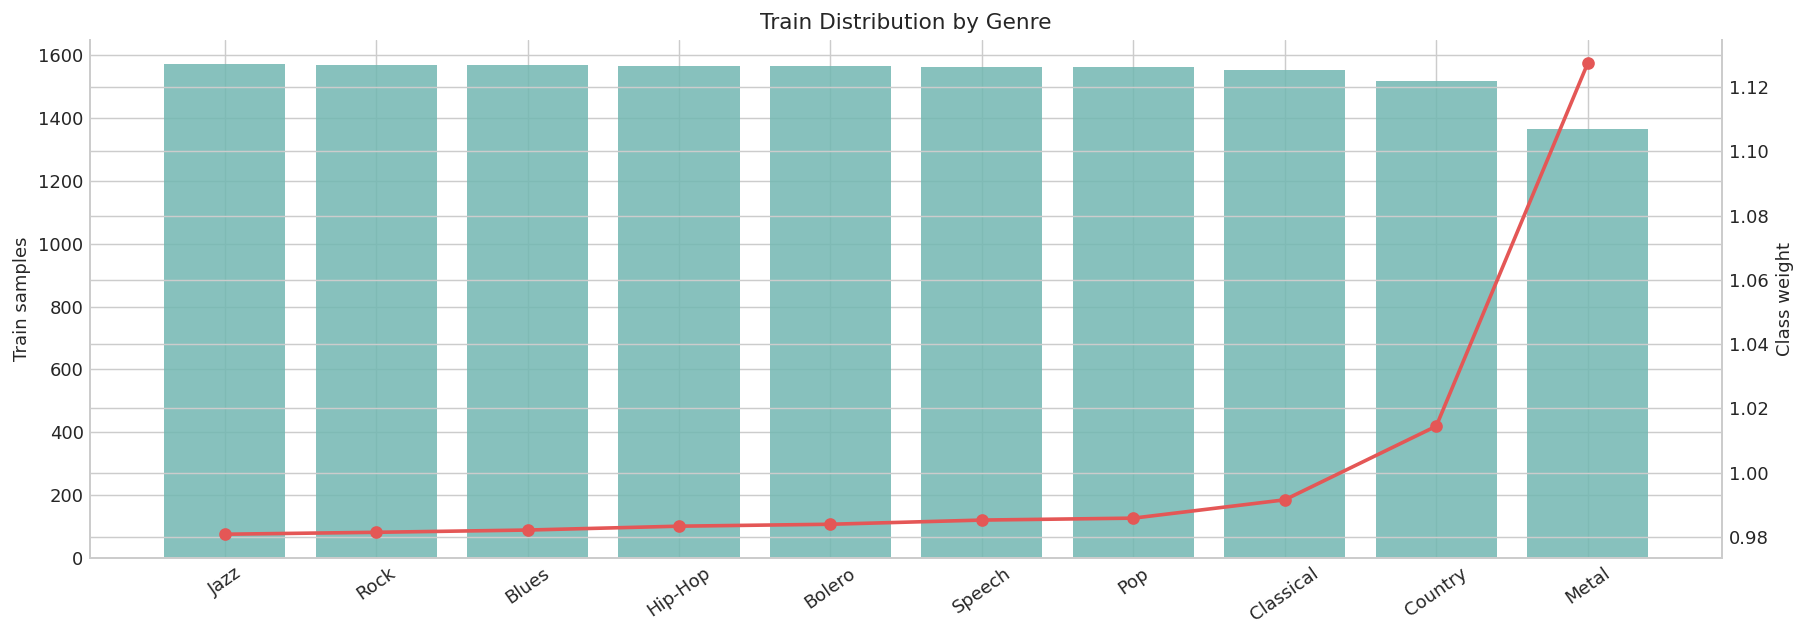

**Most underrepresented class:** Metal with 1367 training samples

In [42]:
display(Markdown('## Dataset Balance and Class Weights'))

genres = report['dataset']['genres']
train_support = {genre: int(report['evaluation']['train']['per_genre'][genre]['support']) for genre in genres}
balance_df = pd.DataFrame({
    'genre': genres,
    'train_support': [train_support[genre] for genre in genres],
    'class_weight': [bundle['class_weights'].get(genre, np.nan) for genre in genres],
}).sort_values('train_support', ascending=False).reset_index(drop=True)

display(balance_df)

fig, ax1 = plt.subplots(figsize=(14, 5), dpi=FIG_DPI)
ax1.bar(balance_df['genre'], balance_df['train_support'], color='#72b7b2', alpha=0.85)
ax1.set_ylabel('Train samples')
ax1.set_title('Train Distribution by Genre')
ax1.tick_params(axis='x', rotation=35)
ax1.spines['top'].set_visible(False)

if balance_df['class_weight'].notna().any():
    ax2 = ax1.twinx()
    ax2.plot(balance_df['genre'], balance_df['class_weight'], color='#e45756', marker='o', linewidth=2.0)
    ax2.set_ylabel('Class weight')
    ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

minority_row = balance_df.sort_values('train_support').iloc[0]
display(Markdown(
    f"**Most underrepresented class:** {minority_row['genre']} with {int(minority_row['train_support'])} training samples"
))

In [43]:
display(Markdown('## Training Dynamics'))

if epochs_df.empty:
    display(Markdown('*No epoch summaries were found in `console_output.txt`.*'))
else:
    fit_accuracy_history = report.get('training', {}).get('fit_accuracy_per_epoch', [])
    train_acc_series = epochs_df['train_acc'].copy()
    train_acc_label = 'Train accuracy'
    if train_acc_series.notna().sum() == 0 and fit_accuracy_history and len(fit_accuracy_history) == len(epochs_df):
        train_acc_series = pd.Series(fit_accuracy_history, index=epochs_df.index, dtype=float)
        train_acc_label = 'Train accuracy (fit metric)'

    if train_acc_series.notna().sum() == 0 and epochs_df['train_macro_f1'].notna().sum() == 0:
        display(Markdown('*Train accuracy and train macro-F1 are unavailable for this run because its epoch summaries only logged validation-side accuracy/F1 and train loss. This run was generated before end-of-epoch clean train evaluation was enabled by default.*'))

    lr_series = pd.Series(report['training'].get('lr_per_epoch', []), index=np.arange(1, len(report['training'].get('lr_per_epoch', [])) + 1))
    sec_series = pd.Series(report['training'].get('seconds_per_epoch', []), index=np.arange(1, len(report['training'].get('seconds_per_epoch', [])) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=FIG_DPI)

    axes[0].plot(epochs_df['epoch'], epochs_df['train_loss'], color='#4c78a8', linewidth=2, label='Train loss')
    axes[0].plot(epochs_df['epoch'], epochs_df['val_loss'], color='#f58518', linewidth=2, label='Validation loss')
    axes[0].set_title('Train and Validation Loss by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    if train_acc_series.notna().any():
        axes[1].plot(epochs_df['epoch'], train_acc_series * 100.0, color='#4c78a8', linewidth=2, label=train_acc_label)
    axes[1].plot(epochs_df['epoch'], epochs_df['val_acc'] * 100.0, color='#54a24b', linewidth=2, label='Validation accuracy (epoch summary only)')
    axes[1].plot(epochs_df['epoch'], epochs_df['val_macro_f1'] * 100.0, color='#e48156', linewidth=2, label='Validation macro-F1 (epoch summary only)')
    axes[1].set_title('Train Accuracy, Validation Accuracy, and Validation Macro-F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Percent')

    for ax in axes:
        if checkpoint_epoch is not None:
            ax.axvline(checkpoint_epoch, color='#9467bd', linestyle='--', linewidth=1.5, label='Best checkpoint')
        if restore_epoch is not None:
            ax.axvline(restore_epoch, color='#8c564b', linestyle=':', linewidth=1.5, label='Restored epoch')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, loc='best')

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), dpi=FIG_DPI)

    if not lr_series.empty:
        axes[0].plot(lr_series.index, lr_series.values, color='#1f77b4', linewidth=2)
        axes[0].set_title('Learning Rate Schedule')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Learning rate')
        axes[0].ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

    if not sec_series.empty:
        axes[1].plot(sec_series.index, sec_series.values, color='#ff7f0e', linewidth=2)
        axes[1].axhline(sec_series.mean(), color='#2ca02c', linestyle='--', linewidth=1.5, label='Mean epoch time')
        axes[1].set_title('Epoch Time')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Seconds')
        axes[1].legend()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    if not sec_series.empty:
        slowest_epoch = int(sec_series.idxmax())
        slowest_seconds = float(sec_series.max())
        display(Markdown(f'**Slowest epoch:** {slowest_epoch} at {slowest_seconds:.1f} seconds'))

## Training Dynamics

*No epoch summaries were found in `console_output.txt`.*

## Per-Genre Evaluation

### Test Set Metrics

,genre,precision,recall,f1-score,support
0,Speech,0.9688,0.9971,0.9827,342
1,Bolero,0.9939,0.9643,0.9789,336
2,Metal,0.9450,0.9386,0.9418,293
3,Classical,0.8780,0.9851,0.9285,336
4,Hip-Hop,0.8524,0.9134,0.8818,335
5,Jazz,0.8514,0.8209,0.8359,335
6,Country,0.8338,0.8262,0.8300,328
7,Rock,0.7878,0.8018,0.7947,338
8,Blues,0.7730,0.8030,0.7877,335
9,Pop,0.8258,0.6586,0.7328,331


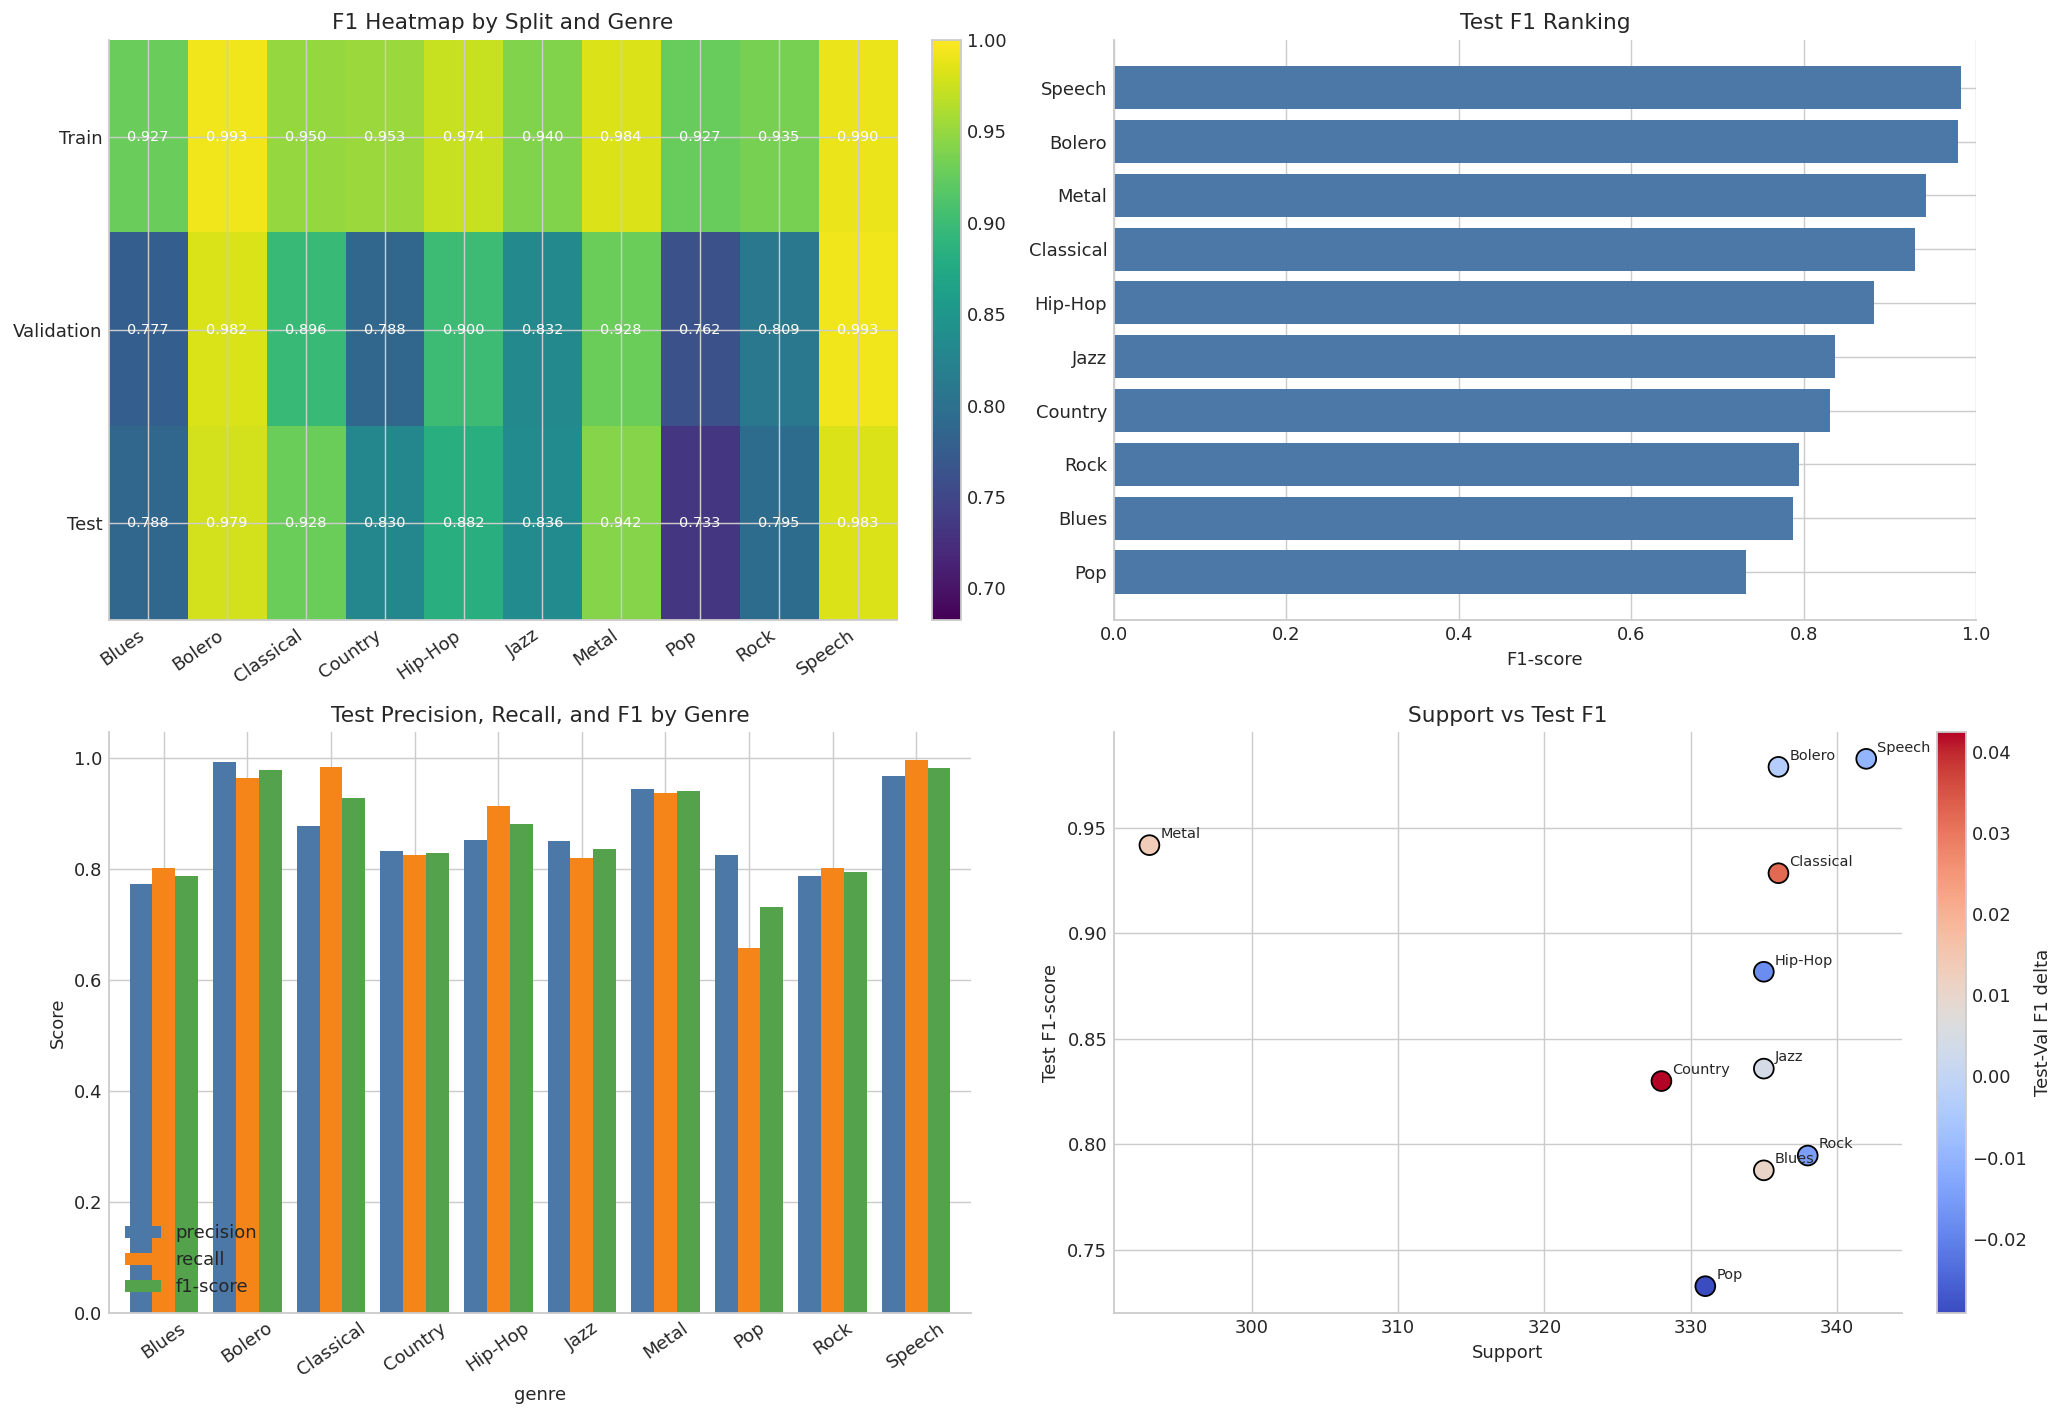

In [44]:
display(Markdown('## Per-Genre Evaluation'))

test_df = per_genre_frames['Test'].copy()
val_df = per_genre_frames['Validation'].copy()
train_df = per_genre_frames['Train'].copy()

display(Markdown('### Test Set Metrics'))
display(test_df.sort_values('f1-score', ascending=False).reset_index(drop=True))

f1_matrix = pd.DataFrame({
    'Train': train_df.set_index('genre')['f1-score'],
    'Validation': val_df.set_index('genre')['f1-score'],
    'Test': test_df.set_index('genre')['f1-score'],
}).T.loc[['Train', 'Validation', 'Test'], genres]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=FIG_DPI)

im = axes[0, 0].imshow(f1_matrix.values, cmap='viridis', aspect='auto', vmin=max(0.0, f1_matrix.values.min() - 0.05), vmax=1.0)
axes[0, 0].set_xticks(np.arange(len(genres)))
axes[0, 0].set_xticklabels(genres, rotation=35, ha='right')
axes[0, 0].set_yticks(np.arange(len(f1_matrix.index)))
axes[0, 0].set_yticklabels(f1_matrix.index)
axes[0, 0].set_title('F1 Heatmap by Split and Genre')
for i in range(f1_matrix.shape[0]):
    for j in range(f1_matrix.shape[1]):
        axes[0, 0].text(j, i, f'{f1_matrix.iloc[i, j]:.3f}', ha='center', va='center', color='white', fontsize=8)
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

test_ranked = test_df.sort_values('f1-score', ascending=False)
axes[0, 1].barh(test_ranked['genre'], test_ranked['f1-score'], color='#4c78a8')
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlim(0.0, 1.0)
axes[0, 1].set_title('Test F1 Ranking')
axes[0, 1].set_xlabel('F1-score')

test_metrics = test_df.set_index('genre')[['precision', 'recall', 'f1-score']]
test_metrics.plot(kind='bar', ax=axes[1, 0], width=0.82, color=['#4c78a8', '#f58518', '#54a24b'])
axes[1, 0].set_title('Test Precision, Recall, and F1 by Genre')
axes[1, 0].set_ylabel('Score')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].legend(loc='lower left')

delta_df = test_df[['genre', 'support', 'f1-score']].merge(
    val_df[['genre', 'f1-score']], on='genre', suffixes=('_test', '_val')
)
delta_df['test_minus_val_f1'] = delta_df['f1-score_test'] - delta_df['f1-score_val']
scatter = axes[1, 1].scatter(delta_df['support'], delta_df['f1-score_test'], c=delta_df['test_minus_val_f1'], s=120, cmap='coolwarm', edgecolor='black')
for _, row in delta_df.iterrows():
    axes[1, 1].annotate(row['genre'], (row['support'], row['f1-score_test']), xytext=(6, 4), textcoords='offset points', fontsize=8)
axes[1, 1].set_title('Support vs Test F1')
axes[1, 1].set_xlabel('Support')
axes[1, 1].set_ylabel('Test F1-score')
fig.colorbar(scatter, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Test-Val F1 delta')

for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Normalization Diagnostics

,type,computed_from,epsilon,stats_artifact,metadata_artifact,mean_per_bin_shape,std_per_bin_shape,mean_per_bin_range,std_per_bin_range
0,train_only_per_mel_bin_standardization,train_split_only,0.0000,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,[192],[192],"[0.0, 1.827329]","[1e-06, 1.657641]"


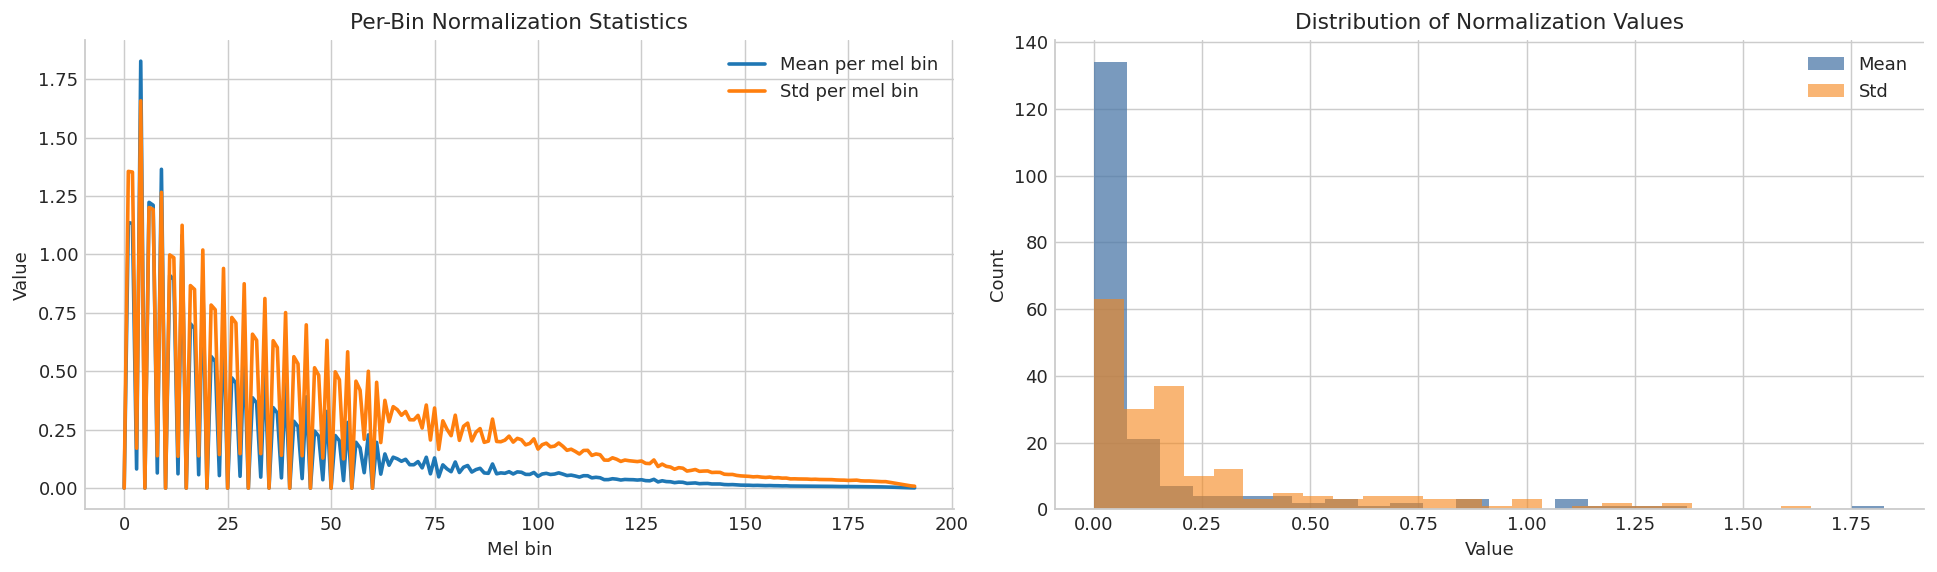

In [45]:
display(Markdown('## Normalization Diagnostics'))

norm_summary_df = pd.DataFrame([report.get('normalization', {})])
display(norm_summary_df)

mean_per_bin = bundle['norm_mean']
std_per_bin = bundle['norm_std']

if mean_per_bin is None or std_per_bin is None:
    display(Markdown('*Per-bin normalization arrays were not found in `norm_stats.npz`.*'))
else:
    mel_bins = np.arange(len(mean_per_bin))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), dpi=FIG_DPI)

    axes[0].plot(mel_bins, mean_per_bin, label='Mean per mel bin', color='#1f77b4', linewidth=2)
    axes[0].plot(mel_bins, std_per_bin, label='Std per mel bin', color='#ff7f0e', linewidth=2)
    axes[0].set_title('Per-Bin Normalization Statistics')
    axes[0].set_xlabel('Mel bin')
    axes[0].set_ylabel('Value')
    axes[0].legend()

    axes[1].hist(mean_per_bin, bins=24, alpha=0.75, label='Mean', color='#4c78a8')
    axes[1].hist(std_per_bin, bins=24, alpha=0.60, label='Std', color='#f58518')
    axes[1].set_title('Distribution of Normalization Values')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Count')
    axes[1].legend()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [46]:
display(Markdown('## Automated Insights and Change Log'))

strongest = test_df.sort_values('f1-score', ascending=False).head(3)
weakest = test_df.sort_values('f1-score', ascending=True).head(3)
recall_gap_row = (test_df.assign(precision_recall_gap=(test_df['precision'] - test_df['recall']).abs())
    .sort_values('precision_recall_gap', ascending=False)
    .iloc[0])

insight_lines = [
    f"- Test performance reached **{report['evaluation']['test']['accuracy'] * 100.0:.2f}% accuracy** and **{report['evaluation']['test']['macro_f1'] * 100.0:.2f}% macro-F1**.",
    f"- The strongest test genres are **{', '.join(strongest['genre'])}** with F1 scores of {', '.join(f'{value:.3f}' for value in strongest['f1-score'])}.",
    f"- The weakest test genres are **{', '.join(weakest['genre'])}** with F1 scores of {', '.join(f'{value:.3f}' for value in weakest['f1-score'])}.",
    f"- The largest precision-recall imbalance appears in **{recall_gap_row['genre']}**, where precision is {recall_gap_row['precision']:.3f} and recall is {recall_gap_row['recall']:.3f}.",
    f"- Standard early stopping restored epoch **{restore_epoch}** while the highest raw validation macro-F1 checkpoint was epoch **{checkpoint_epoch}**." if restore_epoch is not None else f"- The highest raw validation macro-F1 checkpoint was epoch **{checkpoint_epoch}**.",
    f"- Total training time was **{training_hours:.2f} hours** across {report['training']['epochs_actual']} epochs.",
]

display(Markdown('\n'.join(insight_lines)))

if not changes_df.empty:
    display(Markdown('### Version-to-Version Changes Recorded in the Run Report'))
    display(changes_df)

if bundle['model_paths']:
    model_df = pd.DataFrame({'model_file': [path.name for path in bundle['model_paths']]})
    display(Markdown('### Saved Model Files'))
    display(model_df)

## Automated Insights and Change Log

- Test performance reached **87.07% accuracy** and **86.95% macro-F1**.
- The strongest test genres are **Speech, Bolero, Metal** with F1 scores of 0.983, 0.979, 0.942.
- The weakest test genres are **Pop, Blues, Rock** with F1 scores of 0.733, 0.788, 0.795.
- The largest precision-recall imbalance appears in **Pop**, where precision is 0.826 and recall is 0.659.
- Standard early stopping restored epoch **76** while the highest raw validation macro-F1 checkpoint was epoch **83**.
- Total training time was **5.63 hours** across 85 epochs.

### Version-to-Version Changes Recorded in the Run Report

,source_version,change,description
0,v2.1,weight_decay,1e-4 (was 5e-4) — lighter L2 with Mixup+dropou...
1,v2.1,spec_aug_num_masks,1 (was 2) — avoid overmasking combined with Mixup
2,v2.1,spatial_dropout,graduated 0.05/0.10/0.15/0.20 (was flat 0.10) ...
3,v2.1,bottleneck_units,256 (was 128) — preserve full backbone feature...
4,v2.1,final_dropout,0.20 (was 0.25) — wider bottleneck absorbs cap...
5,v2.1,gradient_clipping,clipnorm=1.0 added to AdamW
6,v2.1,class_weight_mixup,pre-Mixup anchor-based weighting (was post-Mix...
7,v2.1,gap_aware_early_stopping,Added macro-F1 gap stopping with threshold=0.1...
8,v2.1,restore_best_weights,Enabled for standard and gap-aware early stopp...
9,v2.2,normalization,Train-only per-mel-bin standardization is now ...


### Saved Model Files

,model_file
0,best_model_macro_f1.keras
1,logmel_cnn_v2_4_1_cuda_tf.keras


In [47]:
display(Markdown('## Optional: Inspect the Saved Keras Model'))

try:
    import tensorflow as tf

    if not bundle['model_paths']:
        display(Markdown('*No `.keras` model file was found in the run directory.*'))
    else:
        model_path = bundle['model_paths'][0]
        model = tf.keras.models.load_model(model_path, compile=False)
        layer_rows = []
        for layer in model.layers:
            output_shape = getattr(layer, 'output_shape', None)
            layer_rows.append({
                'name': layer.name,
                'class_name': layer.__class__.__name__,
                'output_shape': str(output_shape),
                'params': layer.count_params(),
            })
        display(pd.DataFrame(layer_rows))
        model.summary()
except Exception as exc:
    display(Markdown(f'*TensorFlow model inspection skipped:* `{exc}`'))

## Optional: Inspect the Saved Keras Model

2026-03-22 02:27:30.207488: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (100)


,name,class_name,output_shape,params
0,logmel,InputLayer,None,0
1,conv1,Conv2D,None,800
2,bn1,BatchNormalization,None,128
3,relu1,ReLU,None,0
4,pool1,MaxPooling2D,None,0
5,conv2,Conv2D,None,18432
6,bn2,BatchNormalization,None,256
7,relu2,ReLU,None,0
8,sdrop2,SpatialDropout2D,None,0
9,pool2,MaxPooling2D,None,0


Model: "logmel_cnn_v2_4_1_cuda_tf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logmel (InputLayer)             │ (None, 192, 1291, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 192, 1291, 32)  │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 192, 1291, 32)  │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 192, 1291, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 96, 645, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 96, 645, 64)    │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 96, 645, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 96, 645, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop2 (SpatialDropout2D)       │ (None, 96, 645, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 48, 322, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 48, 322, 128)   │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 48, 322, 128)   │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 48, 322, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop3 (SpatialDropout2D)       │ (None, 48, 322, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 24, 161, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 24, 161, 256)   │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 24, 161, 256)   │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 24, 161, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop4 (SpatialDropout2D)       │ (None, 24, 161, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 12, 80, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 12, 80, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 12, 80, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (ReLU)                    │ (None, 12, 80, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop5 (SpatialDropout2D)       │ (None, 12, 80, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 6, 40, 256)     │             

 Total params: 1,049,002 (4.00 MB)

 Trainable params: 1,047,530 (4.00 MB)

 Non-trainable params: 1,472 (5.75 KB)